### 第4章 色彩空间类型转换
#### 4.1 色彩空间基础
##### 4.1.1 GRAY 色彩空间
- Gray (灰度图像) 通常指8位灰度图，具有256个灰度级，像素值的范围是[0, 255]
- 当图像由 RGB 色彩空间转换为 GRAY 色彩空间时，处理方式如下：`Gray = 0.299 * R + 0.587 * G + 0.114 * B`
- 当图像由 GRAY 色彩空间转换为 RGB 色彩空间时，处理方式如下：`R = G = B = Gray`


##### 4.1.2 XYZ 色彩空间
$$
    \begin{bmatrix}
        X \\ Y \\ Z
    \end{bmatrix} = \begin{bmatrix}
                        0.412453 & 0.357580 & 0.180423 \\ 
                        0.212671 & 0.715160 & 0.072169 \\ 
                        0.019334 & 0.119193 & 0.950227 \\
                    \end{bmatrix} \cdot \begin{bmatrix}
                                            R \\ G \\ B
                                        \end{bmatrix}
$$
$$ 
    \begin{bmatrix}
        R \\ G \\ B
    \end{bmatrix} = \begin{bmatrix}
                        3.240479 & -1.53715 & -0.498535 \\ 
                        -0.969256 & 1.875991 & 0.041556 \\ 
                        0.055648 & -0.204043 & 1.057311 \\
                    \end{bmatrix} \cdot \begin{bmatrix}
                                            X \\ Y \\ Z
                                        \end{bmatrix}
$$

##### 4.1.3 YCrCb 色彩空间
- Y 代表光源的亮度, Cr 表示红色分量信息, Cb 表示蓝色分量信息
- 在 RGB 光源中, 绿色分量的影响最大, 蓝色分量的影响最小
$$ \begin{cases}
    Y = 0.299 * R + 0.587 * G + 0.114 * B \\
    Cr = (R - Y) \times 0.713 + delta \\
    Cb = (B - Y) \times 0.564 + delta \\
   \end{cases}
$$
式中 delta 的值为
$$
delta = \begin{cases}
            128, & 8位图像 \\
            32768, & 16位图像 \\  
            0.5, & 单精度图像
        \end{cases}
$$
$$
\begin{cases}
    R = Y + 1.403 * (Cr - delta) \\
    G = Y - 0.714 * (Cr - delta) - 0.344 * (Cb - delta) \\
    B = Y + 1.773 * (Cb - delta)
\end{cases}
$$


##### 4.1.4 HSV 色彩空间
- 色调 (Hue)指光的颜色，与混合光谱中的主要光波长相关
- 饱和度 (Saturation) 指相对纯净度，或一种颜色混合白光的数量。饱和度与所加白光的数量成反比
- 亮度 (Value) 反映的是人眼感受到的光的明暗程度。在其中掺入的白色越多，亮度越高
$$
    S \in [0, 1] \\ 
    V \in [0, 1] \\
    H \in [0, 360]
$$


##### 4.1.5 CIEL\*a\*b\*色彩空间
- CIEL\*a\*b\*是均匀色彩空间模型，它是面向视觉感知的颜色模型。如果人所观察到的两种颜色的区别程度，与这两种颜色在该色彩空间中对应的点之间的欧氏距离成正比，则称该色彩空间为均匀色彩空间。
- L\*分量表示像素的亮度，取值范围是[0, 100]，表示从纯黑到纯白；a\*分量表示从绿色到红色的范围，取值范围是[-127, 127]；b\*分量表示从蓝色到黄色的范围，取值范围是[-127, 127]。
- 从RGB色彩空间转换到CEL\*a\*b\*色彩空间之前，需要先将RGB色彩空间的值转换到[0, 1]之间，然后再进行处理。
- CIEL\*u\*v\*色彩空间类似于CIEL\*a\*b\*色彩空间，都是均匀的颜色模型

##### 4.1.6 Bayer 色彩空间
- 在一个像素点仅使用一块滤镜采集某个特定的颜色分量，该像素点上的其他颜色分量由临近像素点的对应分量值计算得到。
- 在全部滤镜中，有1/2为绿色滤镜、1/4为蓝色滤镜、1/4为红色滤镜。

#### 4.2 相关函数介绍
##### 4.2.1 类型转换函数
`dst = cv2.cvtColor(src, code [, dstCn])`
- 其中
    - dst 表示输出图像，与原始输入图像具有同样的数据类型和深度
    - src 表示原始输入图像
    - code 是色彩空间转换码
    - dstCn 是目标图像的通道数。默认为0，自动通过原始输入图像和 code 得到

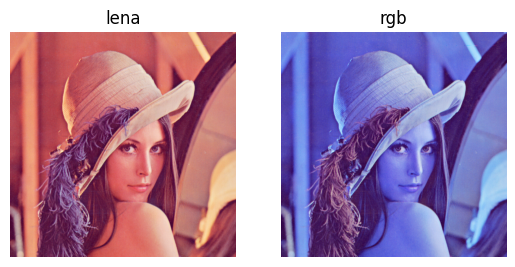

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

lena = cv2.imread("lenacolor.png")
rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

# cv2.imshow("lena", lena)
# cv2.imshow("rgb", rgb)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

plt.subplot(121)
plt.imshow(lena)
plt.title("lena")
plt.axis("off")

plt.subplot(122)
plt.imshow(rgb, cmap="gray")
plt.title("rgb")
plt.axis("off")

plt.show()

##### 4.2.2 标记指定颜色
`dst = cv2.inRange(src, lowerb, upperb)`
- 其中
    - dst 表示输出结果，大小和src一致；如果src值在指定区间内，则dst对应位置的值为255，否则为0
    - src 表示要检查的数组或图像
    - lowerb 表示范围下界
    - upperb 表示范围上界

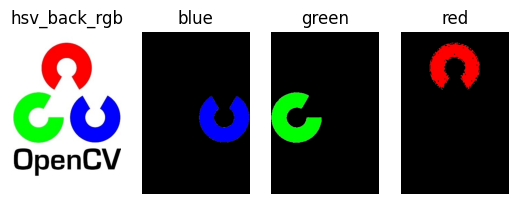

In [ ]:
# 通过基于掩码的按位与操作，显示图像中指定颜色的区域
import cv2
import numpy as np

opencv = cv2.imread("opencv.jpg")
hsv = cv2.cvtColor(opencv, cv2.COLOR_BGR2HSV)
# cv2.imshow('opencv', opencv) # OpenCV 可以正常显示
#=============指定蓝色值的范围=============
minBlue = np.array([110, 100, 100])
maxBlue = np.array([130, 255, 255])
#确定蓝色区域
mask = cv2.inRange(hsv, minBlue, maxBlue)
#通过掩码控制的按位与，锁定蓝色区域
blue = cv2.bitwise_and(opencv, opencv, mask=mask)
# cv2.imshow('blue',blue)
#=============指定绿色值的范围=============
minGreen = np.array([50, 100, 100])
maxGreen = np.array([70, 255, 255])
#确定绿色区域
mask = cv2.inRange(hsv, minGreen, maxGreen)
#通过掩码控制的按位与，锁定绿色区域
green = cv2.bitwise_and(opencv, opencv, mask=mask)
# cv2.imshow('green', green)
#=============指定红色值的范围=============
minRed = np.array([0, 100, 100])
maxRed = np.array([10, 255, 255])
#确定红色区域
mask = cv2.inRange(hsv, minRed, maxRed)
#通过掩码控制的按位与，锁定红色区域
red= cv2.bitwise_and(opencv, opencv, mask=mask)
# cv2.imshow('red', red)
cv2.waitKey(0)
cv2.destroyAllWindows()

hsv_back_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB) # HSV图像转换为RGB图像，才能正确显示
blue = cv2.cvtColor(blue, cv2.COLOR_BGR2RGB)
green = cv2.cvtColor(green, cv2.COLOR_BGR2RGB)
red = cv2.cvtColor(red, cv2.COLOR_BGR2RGB)

plt.subplot(141)
plt.imshow(hsv_back_rgb)
plt.title("hsv_back_rgb")
plt.axis("off")

plt.subplot(142)
plt.imshow(blue)
plt.title("blue")
plt.axis("off")

plt.subplot(143)
plt.imshow(green)
plt.title("green")
plt.axis("off")

plt.subplot(144)
plt.imshow(red)
plt.title("red")
plt.axis("off")

plt.show()

##### 4.2.3 调整HSV色彩空间的分量值

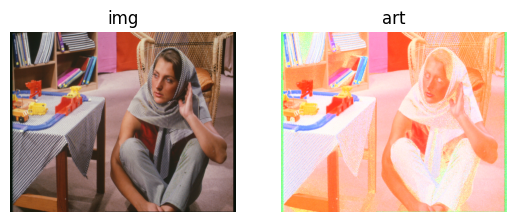

In [12]:
import cv2
img = cv2.imread("barbara.bmp")
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(hsv)
v[:, :] = 255   # 改变V值为255
newHSV = cv2.merge([h, s, v])
art = cv2.cvtColor(newHSV, cv2.COLOR_HSV2BGR)

# cv2.imshow("img", img)
# cv2.imshow("art", art)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
art = cv2.cvtColor(art, cv2.COLOR_BGR2RGB)

plt.subplot(121)
plt.imshow(img)
plt.title("img")
plt.axis("off")

plt.subplot(122)
plt.imshow(art)
plt.title("art")
plt.axis("off")
plt.show()

#### 4.3 alpha通道
- 在RGB色彩空间基础上，增加一个A通道，也叫alpha通道，表示透明度，这种色彩空间称为RGBA色彩空间
- PNG图像是一种典型的4通道图像

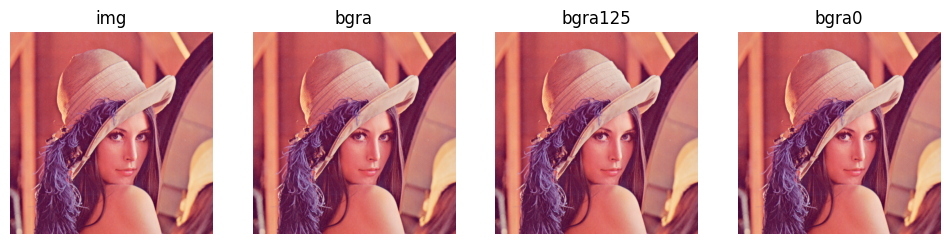

In [ ]:
import cv2
img = cv2.imread("lenacolor.png")
bgra = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
b, g, r, a = cv2.split(bgra)
a[:, :] = 125
bgra125 = cv2.merge([b, g, r, a])
a[:, :] = 0     # 将alpha通道的值设置为0，完全透明
bgra0 = cv2.merge([b, g, r, a])
# cv2.imshow("img", img)
# cv2.imshow("bgra", bgra)
# cv2.imshow("bgra125", bgra125)
# cv2.imshow("bgra0", bgra0)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

cv2.imwrite("bgra.png", bgra)
cv2.imwrite("bgra125.png", bgra125)
cv2.imwrite("bgra0.png", bgra0)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
bgra = cv2.cvtColor(bgra, cv2.COLOR_BGR2RGB)
bgra125 = cv2.cvtColor(bgra125, cv2.COLOR_BGR2RGB)
bgra0 = cv2.cvtColor(bgra0, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(141)
plt.imshow(img)
plt.title("img")
plt.axis("off")

plt.subplot(142)
plt.imshow(bgra)
plt.title("bgra")
plt.axis("off")

plt.subplot(143)
plt.imshow(bgra125)
plt.title("bgra125")
plt.axis("off")

plt.subplot(144)
plt.imshow(bgra0)
plt.title("bgra0")
plt.axis("off")

plt.show()
# matplotlib 不显示 Alpha 透明通道！

- 以Markdown格式直接插入图片，显示透明效果

<img src="bgra.png" width="20%">
<img src="bgra125.png" width="20%">
<img src="bgra0.png" width="20%">